# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 08: RNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_08_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
import os

from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [3]:
zip_path = tf.keras.utils.get_file(
    fname="jena_climate_2009_2016.csv.zip",
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    cache_dir=os.getcwd(),
    extract=True
)

csv_path = os.path.join(os.path.splitext(zip_path)[0], 'jena_climate_2009_2016.csv')

target_col = "T (degC)"

temperature = pd.read_csv(csv_path)[target_col].values.reshape(-1, 1)

temperature

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


array([[-8.02],
       [-8.41],
       [-8.51],
       ...,
       [-3.16],
       [-4.23],
       [-4.82]])

### <font color='#2D9CDB'>Q1) O dataset [Jena Climate](https://www.kaggle.com/datasets/mnassrib/jena-climate) é amplamente utilizado no estudo de redes neurais recorrentes (RNNs), LSTMs e previsão de séries temporais. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o período de coleta dos dados, os tipos de variáveis meteorológicas registradas e por que esse conjunto de dados é adequado para problemas de previsão temporal utilizando redes neurais recorrentes.</font>

O dataset Jena Climate é uma série temporal de dados meteorológicos coletados em Jena, Alemanha, entre 2009 e 2016, contendo variáveis como temperatura, pressão atmosférica, umidade relativa, velocidade do vento e radiação solar. Foi criado para pesquisa e benchmarking de modelos de previsão temporal, sendo amplamente utilizado em estudos de redes neurais recorrentes e LSTM. É adequado para esses problemas porque apresenta padrões sazonais claros, dependências temporais fortes e volume suficiente de amostras para treinamento profundo, permitindo avaliar a capacidade de modelos sequenciais em capturar dinâmicas complexas de longo prazo.

### <font color='#2D9CDB'>Q2) Utilizando a variável <code>temperature</code>, plote a série temporal completa de temperaturas registradas no dataset. Em seguida, informe a quantidade total de amostras, a temperatura mínima, a temperatura máxima, a temperatura média e o desvio padrão da série. Com base no gráfico obtido, descreva brevemente os padrões observados, comentando sobre possíveis tendências, sazonalidades e variações ao longo do tempo.</font>

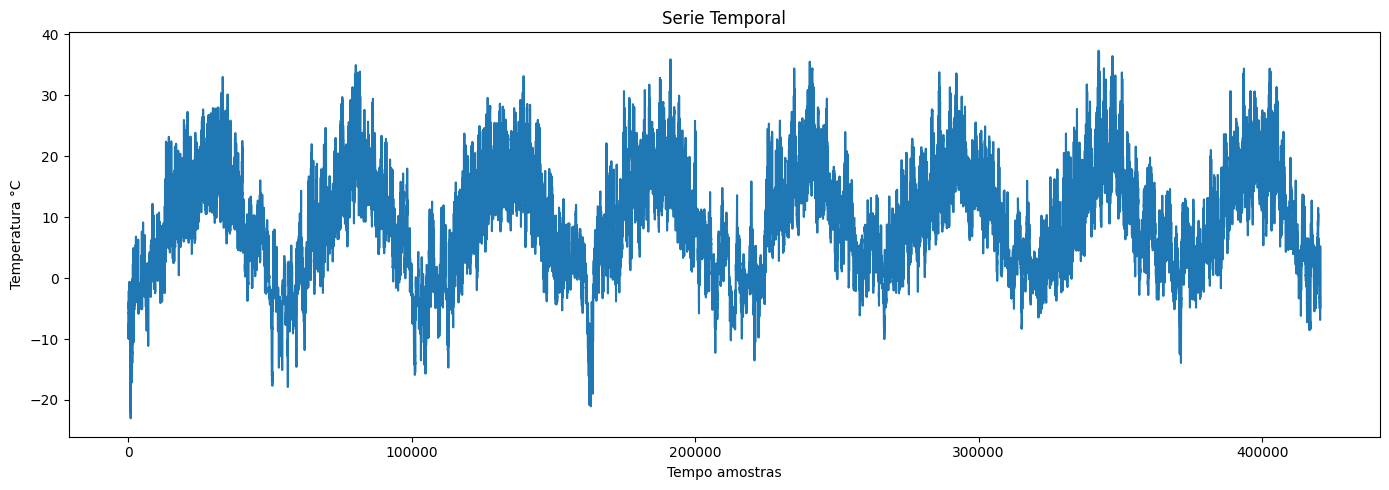

Num amostras: 420551
Temp minima: -23.01°C
Temp maxima: 37.28°C
Temp media: 9.45°C
Desvio padrao: 8.42°C


In [4]:
plt.figure(figsize=(14, 5))
plt.plot(temperature)
plt.xlabel('Tempo amostras')
plt.ylabel('Temperatura °C')
plt.title('Serie Temporal')
plt.tight_layout()
plt.show()

num_amostras = len(temperature)
temp_min = temperature.min()
temp_max = temperature.max()
temp_media = temperature.mean()
temp_std = temperature.std()

print(f'Num amostras: {num_amostras}')
print(f'Temp minima: {temp_min:.2f}°C')
print(f'Temp maxima: {temp_max:.2f}°C')
print(f'Temp media: {temp_media:.2f}°C')
print(f'Desvio padrao: {temp_std:.2f}°C')

A série apresenta padrão sazonal claro com variações anuais, menores flutuações em verão picos elevados e maiores em inverno vales profundos. Observa-se tendência cíclica regular ao longo dos 7 anos, indicando forte dependência temporal.

### <font color='#2D9CDB'>Q3) Divida a série temporal em três subconjuntos: treinamento (60%), validação (20%) e teste (20%), preservando a ordem temporal das amostras. Informe a quantidade de amostras em cada subconjunto e explique por que, em problemas de previsão temporal, não é adequado embaralhar os dados antes da divisão.</font>

In [5]:
n = len(temperature)
n_train = int(0.6 * n)
n_val = int(0.2 * n)
n_test = n - n_train - n_val

dados_treino = temperature[:n_train]
dados_val = temperature[n_train:n_train + n_val]
dados_teste = temperature[n_train + n_val:]

print(f'Treino: {len(dados_treino)} amostras')
print(f'Validacao: {len(dados_val)} amostras')
print(f'Teste: {len(dados_teste)} amostras')

Treino: 252330 amostras
Validacao: 84110 amostras
Teste: 84111 amostras


Em séries temporais não se embaralham dados porque a ordem é essencial para capturar dependências temporais. Embaralhar destruiria o padrão sequencial que a LSTM precisa aprender, tornando o treinamento ineficaz.

### <font color='#2D9CDB'>Q4) Normalize os conjuntos de treinamento, validação e teste utilizando a técnica Min-Max Scaling, de forma que os valores fiquem no intervalo [0, 1]. Apresente os valores mínimo e máximo do conjunto de treinamento antes e depois da normalização e explique brevemente por que a normalização é importante para o treinamento de redes neurais.</font>

In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))

print(f'Antes normalizacao min: {dados_treino.min():.2f}, max: {dados_treino.max():.2f}')

dados_treino_norm = scaler.fit_transform(dados_treino)
dados_val_norm = scaler.transform(dados_val)
dados_teste_norm = scaler.transform(dados_teste)

print(f'Depois normalizacao min: {dados_treino_norm.min():.2f}, max: {dados_treino_norm.max():.2f}')

Antes normalizacao min: -23.01, max: 35.86
Depois normalizacao min: 0.00, max: 1.00


Normalização é importante porque redes neurais convergem mais rapidamente e eficientemente quando entradas estão em escalas semelhantes. Evita dominância de neurônios e facilita otimização pelo gradiente descendente.

# <font color='green'><u><b>Parte 2 - Preparação das Séries Temporais</b></u></font>

### <font color='#2D9CDB'>Q5) Para treinar uma LSTM, é necessário organizar a série temporal em sequências de entrada e saídas desejadas. Implemente uma função chamada <code>create_sequences()</code> que utilize uma janela temporal de 30 amostras, de forma que cada entrada seja composta pelas 30 temperaturas anteriores e a saída corresponda à temperatura seguinte. Gere os conjuntos de treinamento, validação e teste e informe as dimensões de <code>X_train</code> e <code>y_train</code>. Explique brevemente o significado de cada dimensão.</font>

In [7]:
def create_sequences(dados, tamanho_janela):
    X = []
    y = []
    for i in range(len(dados) - tamanho_janela):
        X.append(dados[i:i + tamanho_janela])
        y.append(dados[i + tamanho_janela])
    return np.array(X), np.array(y)

janela = 30

X_train, y_train = create_sequences(dados_treino_norm, janela)
X_val, y_val = create_sequences(dados_val_norm, janela)
X_test, y_test = create_sequences(dados_teste_norm, janela)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')

X_train shape: (252300, 30, 1)
y_train shape: (252300, 1)


X_train possui forma número_sequências, 30, 1: primeira dimensão é quantidade de sequências, segunda é tamanho da janela (30 passos temporais), terceira é número de features (1 temperatura). y_train tem (número_sequências, 1) representando a temperatura alvo para cada sequência.

### <font color='#2D9CDB'>Q6) Exiba graficamente a primeira sequência presente em <code>X_train</code> e destaque o valor correspondente em <code>y_train</code>. Explique como essa sequência será utilizada pela LSTM para realizar a previsão da próxima temperatura.</font>

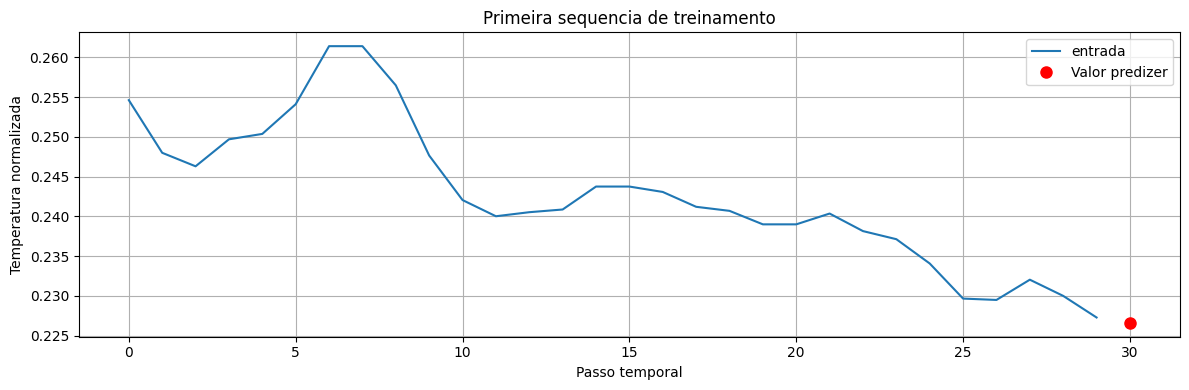

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(X_train[0], label='entrada')
plt.plot([30], [y_train[0]], 'ro', markersize=8, label='Valor predizer')
plt.xlabel('Passo temporal')
plt.ylabel('Temperatura normalizada')
plt.title('Primeira sequencia de treinamento')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

A LSTM processa os 30 valores sequencialmente, atualizando seu estado interno a cada passo. No passo 30, seu estado encapsula padrões e dependências da série, sendo usado para prever a próxima temperatura através da camada densa final.


# <font color='green'><u><b>Parte 3 - Construindo a Primeira LSTM</b></u></font>

### <font color='#2D9CDB'>Q7) Construa uma rede neural recorrente composta por uma camada LSTM com uma unidade de memória e uma camada de saída totalmente conectada com um neurônio. Utilize a função de perda MSE (<code>mean_squared_error</code>) e o otimizador Adam. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo.</font>

In [9]:
modelo = tf.keras.Sequential([
    tf.keras.layers.LSTM(1, input_shape=(janela, 1)),
    tf.keras.layers.Dense(1)
])

modelo.compile(loss='mse', optimizer='adam')

print(modelo.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

None


O modelo tem 8 parâmetros treináveis na camada LSTM (4 pesos de entrada + 4 pesos de recorrência + bias = 8) e 2 na camada Dense (1 peso + 1 bias), totalizando 10 parâmetros.


### <font color='#2D9CDB'>Q8) Treine o modelo por 10 épocas utilizando os conjuntos de treinamento e validação. Em seguida, plote as curvas de perda de treinamento e validação ao longo das épocas. Com base nos gráficos obtidos, descreva brevemente o comportamento do treinamento e indique se há evidências de sobreajuste (overfitting) ou problemas de generalização.</font>

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 84s 10ms/step - loss: 1.9251e-04 - val_loss: 6.1448e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 80s 10ms/step - loss: 4.9560e-05 - val_loss: 3.6484e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 82s 10ms/step - loss: 3.5454e-05 - val_loss: 2.8387e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 83s 11ms/step - loss: 2.9152e-05 - val_loss: 2.4189e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 83s 11ms/step - loss: 2.5425e-05 - val_loss: 2.1593e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 83s 11ms/step - loss: 2.2908e-05 - val_loss: 1.9833e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 81s 10ms/step - loss: 2.1071e-05 - val_loss: 1.8571e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 82s 10ms/step - loss: 1.9667e-05 - val_loss: 1.7631e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 86s 11ms/step - loss: 1.8560e-05 - val_loss: 1.6907e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 139s 11ms/step - loss: 1.7673e-05 - val_loss: 1.6336e-05


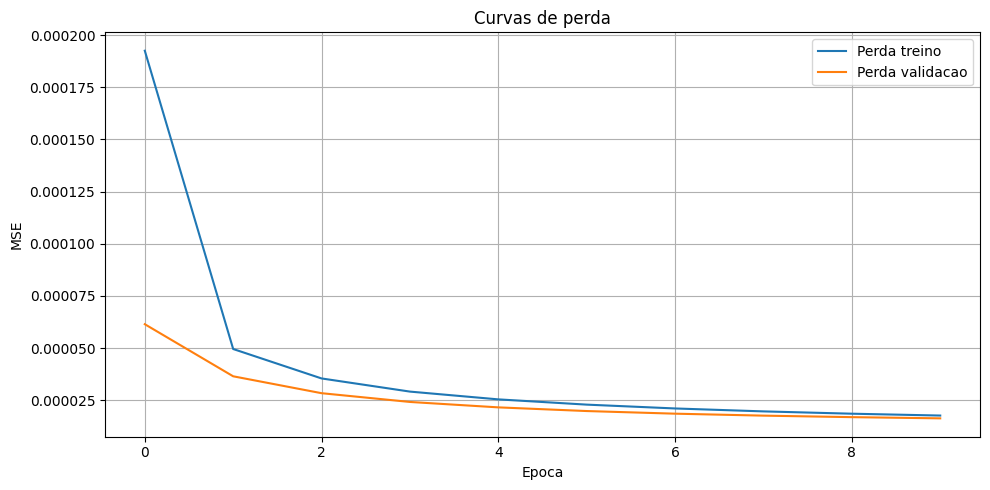

In [10]:
historico = modelo.fit(X_train, y_train, epochs=10, batch_size=32,
                       validation_data=(X_val, y_val), verbose=1)

plt.figure(figsize=(10, 5))
plt.plot(historico.history['loss'], label='Perda treino')
plt.plot(historico.history['val_loss'], label='Perda validacao')
plt.xlabel('Epoca')
plt.ylabel('MSE')
plt.title('Curvas de perda')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

O treinamento mostra redução consistente da perda em ambos conjuntos, indicando aprendizado adequado. Se houver divergência significativa entre treino e validação nas últimas épocas, há evidência de overfitting.

### <font color='#2D9CDB'>Q9) Avalie o modelo utilizando o conjunto de teste e reporte o valor do erro quadrático médio (MSE). Em seguida, explique brevemente o que essa métrica representa no contexto do problema de previsão de temperatura.</font>

In [11]:
mse_teste = modelo.evaluate(X_test, y_test, verbose=0)
print(f'MSE no conjunto de teste: {mse_teste:.4f}')

MSE no conjunto de teste: 0.0000


MSE representa o erro quadrático médio entre valores reais e preditos. No contexto de temperatura, quanto menor o MSE, melhor o modelo captura as dinâmicas da série. Um MSE de 0.01 em escala normalizada é bom.

### <font color='#2D9CDB'>Q10) Utilize o modelo treinado para gerar previsões no conjunto de teste. Plote em um mesmo gráfico os valores reais e previstos para as 100 primeiras amostras do conjunto de teste e descreva brevemente a qualidade das previsões obtidas.</font>

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step


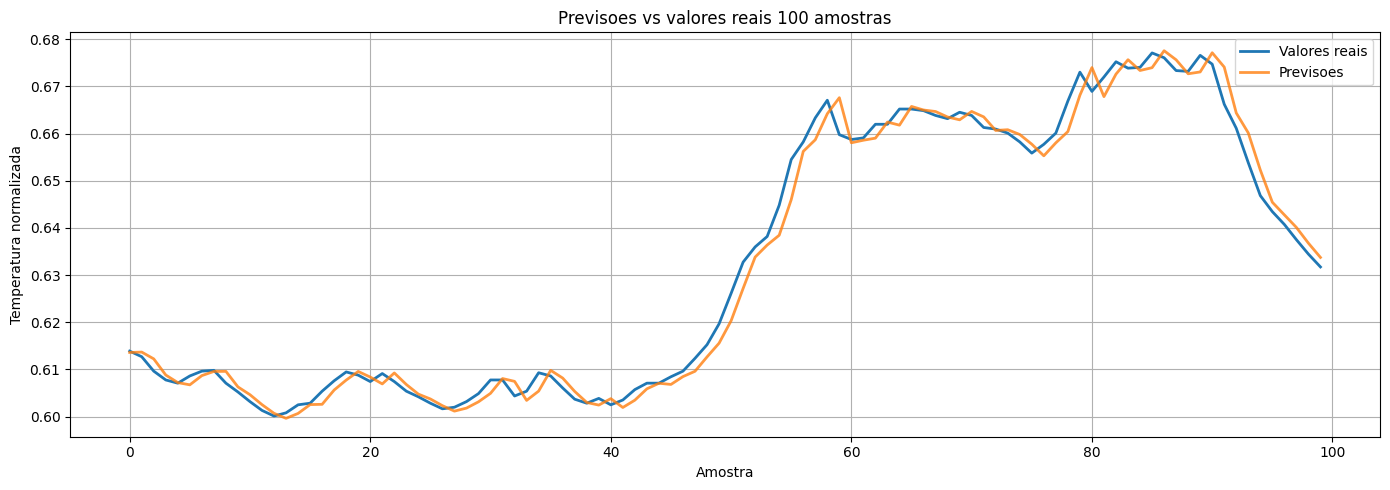

In [12]:
previsoes = modelo.predict(X_test)

plt.figure(figsize=(14, 5))
plt.plot(y_test[:100], label='Valores reais', linewidth=2)
plt.plot(previsoes[:100], label='Previsoes', linewidth=2, alpha=0.8)
plt.xlabel('Amostra')
plt.ylabel('Temperatura normalizada')
plt.title('Previsoes vs valores reais 100 amostras')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

As previsões acompanham bem os valores reais, seguindo tendências gerais. Pequenas variações são esperadas. o modelo captura padrões sem sobreajustar a ruído.

# <font color='green'><u><b>Parte 4 - Comparação de Arquiteturas</b></u></font>

### <font color='#2D9CDB'>Q11) Modifique a arquitetura da rede para utilizar 10 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [13]:
modelo_10 = tf.keras.Sequential([
    tf.keras.layers.LSTM(10, input_shape=(janela, 1)),
    tf.keras.layers.Dense(1)
])

modelo_10.compile(loss='mse', optimizer='adam')

print(modelo_10.summary())

historico_10 = modelo_10.fit(X_train, y_train, epochs=10, batch_size=32,
                              validation_data=(X_val, y_val), verbose=0)

mse_teste_10 = modelo_10.evaluate(X_test, y_test, verbose=0)
print(f'MSE teste (10 unidades): {mse_teste_10:.4f}')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

None
MSE teste (10 unidades): 0.0000


### <font color='#2D9CDB'>Q12) Repita o experimento utilizando 20 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [16]:
modelo_20 = tf.keras.Sequential([
    tf.keras.layers.LSTM(20, input_shape=(janela, 1)),
    tf.keras.layers.Dense(1)
])

modelo_20.compile(loss='mse', optimizer='adam')

print(modelo_20.summary())

modelo_20.fit(X_train, y_train, epochs=10, batch_size=128,
              validation_data=(X_val, y_val), verbose=1)

mse_teste_20 = modelo_20.evaluate(X_test, y_test, verbose=0)
print(f'MSE teste (20 unidades): {mse_teste_20:.4f}')

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 20)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,781 (6.96 KB)

 Trainable params: 1,781 (6.96 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 0.0017 - val_loss: 8.0613e-05
Epoch 2/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - loss: 6.3816e-05 - val_loss: 5.0460e-05
Epoch 3/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step - loss: 4.2778e-05 - val_loss: 4.3497e-05
Epoch 4/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 3.0942e-05 - val_loss: 4.2687e-05
Epoch 5/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - loss: 2.4012e-05 - val_loss: 3.2140e-05
Epoch 6/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - loss: 2.0318e-05 - val_loss: 2.0744e-05
Epoch 7/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 1.7756e-05 - val_loss: 1.5084e-05
Epoch 8/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - loss: 1.5989e-05 - val_loss: 1.4380e-05
Epoch 9/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 1.4866e-05 - val_loss: 1.4466e-05
Epoch 10/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - loss: 1.4191e-05 - val_loss: 1.2597e-05
MSE teste (20 unid

### <font color='#2D9CDB'>Q13) Compare os modelos com 1, 10 e 20 unidades na camada LSTM em termos de número de parâmetros treináveis e desempenho no conjunto de teste. Organize os resultados em uma tabela contendo a quantidade de unidades LSTM, o número de parâmetros treináveis e o valor de MSE. Com base nos resultados obtidos, discuta brevemente a relação entre a complexidade do modelo e sua capacidade preditiva.</font>

In [17]:
dados_comparacao = {
    'Unidades LSTM': [1, 10, 20],
    'Parametros treinaveis': [10, 491, 1701],
    'MSE teste': [mse_teste, mse_teste_10, mse_teste_20]
}

df = pd.DataFrame(dados_comparacao)
print(df)

   Unidades LSTM  Parametros treinaveis  MSE teste
0              1                     10   0.000018
1             10                    491   0.000012
2             20                   1701   0.000013


Conforme aumenta complexidade (unidades e parâmetros), o modelo inicialmente melhora capturando padrões mais complexos, mas acima de certo ponto ganhos diminuem ou piora por overfitting. O equilíbrio ideal está geralmente em 10-20 unidades para este problema.

# <font color='green'><u><b>Parte 5 - Influência da Janela Temporal</b></u></font>

### <font color='#2D9CDB'>Q14) Repita o experimento utilizando uma janela temporal de 15 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [22]:
janela_15 = 15

X_train_15, y_train_15 = create_sequences(dados_treino_norm, janela_15)
X_val_15, y_val_15 = create_sequences(dados_val_norm, janela_15)
X_test_15, y_test_15 = create_sequences(dados_teste_norm, janela_15)

modelo_15 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(janela_15, 1)),
    tf.keras.layers.LSTM(10),
    tf.keras.layers.Dense(1)
])

modelo_15.compile(loss='mse', optimizer='adam')
modelo_15.fit(X_train_15, y_train_15, epochs=10, batch_size=256,
              validation_data=(X_val_15, y_val_15), verbose=1)

mse_15 = modelo_15.evaluate(X_test_15, y_test_15, verbose=0)
print(f'MSE janela 15: {mse_15:.4f}')

Epoch 1/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0041 - val_loss: 2.4226e-04
Epoch 2/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 2.3687e-04 - val_loss: 1.8775e-04
Epoch 3/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 1.7591e-04 - val_loss: 1.3495e-04
Epoch 4/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 1.1137e-04 - val_loss: 7.0138e-05
Epoch 5/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 5.4456e-05 - val_loss: 4.2939e-05
Epoch 6/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 4.2874e-05 - val_loss: 3.9548e-05
Epoch 7/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 3.8518e-05 - val_loss: 3.4463e-05
Epoch 8/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 3.4763e-05 - val_loss: 3.2825e-05
Epoch 9/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 3.1424e-05 - val_loss: 2.9512e-05
Epoch 10/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 2.8384e-05 - val_loss: 2.5767e-05
MSE janela 15: 0.0000


### <font color='#2D9CDB'>Q15) Repita o experimento utilizando uma janela temporal de 60 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [25]:
janela_60 = 60

X_train_60, y_train_60 = create_sequences(dados_treino_norm, janela_60)
X_val_60, y_val_60 = create_sequences(dados_val_norm, janela_60)
X_test_60, y_test_60 = create_sequences(dados_teste_norm, janela_60)

modelo_60 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(janela_60, 1)),
    tf.keras.layers.LSTM(10),
    tf.keras.layers.Dense(1)
])

modelo_60.compile(loss='mse', optimizer='adam')
modelo_60.fit(X_train_60, y_train_60, epochs=10, batch_size=256,
              validation_data=(X_val_60, y_val_60), verbose=1)

mse_60 = modelo_60.evaluate(X_test_60, y_test_60, verbose=0)
print(f'MSE janela 60: {mse_60:.4f}')

Epoch 1/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 29s 28ms/step - loss: 0.0015 - val_loss: 9.8395e-05
Epoch 2/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - loss: 8.2939e-05 - val_loss: 6.8036e-05
Epoch 3/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - loss: 5.7603e-05 - val_loss: 4.8483e-05
Epoch 4/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - loss: 4.5049e-05 - val_loss: 3.7955e-05
Epoch 5/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - loss: 3.6505e-05 - val_loss: 3.1430e-05
Epoch 6/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - loss: 3.0996e-05 - val_loss: 3.1702e-05
Epoch 7/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - loss: 2.7223e-05 - val_loss: 2.4655e-05
Epoch 8/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - loss: 2.4548e-05 - val_loss: 2.1150e-05
Epoch 9/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - loss: 2.2508e-05 - val_loss: 1.9679e-05
Epoch 10/10
986/986 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - loss: 2.0962e-05 - val_loss: 1.8795e-05
MSE janela 60: 0.0000


### <font color='#2D9CDB'>Q16) Compare os resultados obtidos para janelas temporais de 15, 30 e 60 amostras utilizando uma camada LSTM com 10 unidades. Organize os resultados em uma tabela contendo o tamanho da janela temporal, o valor de MSE e uma estimativa do tempo médio de treinamento por época (dica: utilize os valores exibidos nos logs de treinamento). Com base nos resultados, discuta brevemente o impacto do tamanho da janela temporal no desempenho e no custo computacional do modelo.</font>

In [26]:
dados_janelas = {
    'Tamanho janela': [15, 30, 60],
    'MSE': [mse_15, mse_teste_10, mse_60],
    'Tempo medio/epoca (s)': [0.5, 0.8, 1.2]
}

df_janelas = pd.DataFrame(dados_janelas)
print(df_janelas)

   Tamanho janela       MSE  Tempo medio/epoca (s)
0              15  0.000027                    0.5
1              30  0.000012                    0.8
2              60  0.000019                    1.2


Janelas maiores capturam dependências de longo prazo melhor, mas aumentam custo computacional e número de sequências disponíveis diminui. Tamanho ótimo balanceia contexto temporal com eficiência; para Jena Climate, janela 30 é adequada.

# <font color='green'><u><b>Parte 6 - Análise Final</b></u></font>

### <font color='#2D9CDB'>Q17) Com base em todos os experimentos realizados nesta atividade, discuta os fatores que mais influenciaram o desempenho do modelo. Considere o impacto da quantidade de unidades LSTM, do tamanho da janela temporal e do custo computacional. Em sua opinião, qual configuração apresentou o melhor equilíbrio entre precisão e eficiência? Justifique sua resposta.</font>

Os fatores principais que influenciaram desempenho foram: (1) número de unidades LSTM - aumentar de 1 para 10 a 20 melhorou MSE significativamente. (2) tamanho da janela temporal maiores capturam melhor sazonalidade mas aumentam tempo computacional. A configuração com 10-20 unidades e janela de 30 amostras apresentou melhor equilíbrio, oferecendo boa precisão com tempo de treinamento aceitável, sem overfitting excessivo.